# 🎙️ Pipeline Prétraitement & Augmentation — Whisper

**Objectif :** Prendre en charge des paires audio-texte brutes, filtrer les données de mauvaise qualité, isoler la voix, et augmenter les données pour le fine-tuning Whisper.

## Architecture

```
INPUT : Paires (audio .wav/.mp3, texte) brutes
  │
  ├── ZONE A : Normalisation audio
  │     └── Conversion 16kHz mono, normalisation volume
  │
  ├── ZONE B : Séparation source — Focus voix
  │     ├── Demucs htdemucs (GPU) → isole la piste vocale
  │     └── noisereduce (CPU fallback) → réduction spectrale du bruit
  │
  ├── ZONE C : Filtres de qualité
  │     ├── Durée (min / max)
  │     ├── SNR — Signal-to-Noise Ratio
  │     ├── RMS — énergie (silence / saturation)
  │     ├── VAD — Voice Activity Detection
  │     └── WER — cohérence audio/texte via Whisper
  │
  ├── ZONE D : Augmentation des données
  │     ├── Bruit additif (blanc, rose, babble)
  │     ├── Room Impulse Response (simulation acoustique)
  │     ├── Time-stretching (±10% tempo)
  │     ├── Pitch-shifting (±2 demi-tons)
  │     └── Volume perturbation (±6 dB)
  │
  └── ZONE E : Export JSONL
        └── Données prêtes pour fine-tuning Whisper
```

---
## Zone 0 : Installation & Configuration

In [1]:
!apt-get install -y ffmpeg > /dev/null 2>&1

!pip install -q \
    demucs \
    noisereduce \
    librosa \
    soundfile \
    audiomentations \
    openai-whisper \
    jiwer \
    tqdm \
    numpy \
    pandas \
    matplotlib \
    scipy

print('✅ Installation terminée')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 53.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.1/87.1 kB 9.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 693.0 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.3/249.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.2 MB/s eta 0:00:00
   ━━━━━

In [2]:
import json
import shutil
import subprocess
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
print(f'Device   : {DEVICE}')

PyTorch  : 2.10.0+cu128
CUDA     : True
Device   : cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
#  CONFIGURATION — Adapter selon ton environnement
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Entrée ───────────────────────────────────────────────────────────────
    # Option 1 : dossier avec audio + fichiers texte (.txt ou .json)
    "input_audio_dir"    : Path("/content/drive/MyDrive/asr/data/raw_audio"),
    # Option 2 : fichier JSONL  {"audio_path": "...", "text": "..."}
    "input_jsonl"        : Path("/content/drive/MyDrive/asr/output/input_pairs.jsonl"),
    # Choisir le mode d'entrée : 'jsonl' ou 'folder'
    "input_mode"         : "jsonl",

    # ── Sorties ──────────────────────────────────────────────────────────────
    "output_dir"         : Path("/content/drive/MyDrive/asr/output/preprocessed"),
    "voice_dir"          : Path("/content/drive/MyDrive/asr/output/voice_separated"),
    "augmented_dir"      : Path("/content/drive/MyDrive/asr/output/augmented"),

    # ── Audio ────────────────────────────────────────────────────────────────
    "sample_rate"        : 16000,
    "audio_extensions"   : [".wav", ".mp3", ".m4a", ".flac", ".ogg"],

    # ── Séparation source ────────────────────────────────────────────────────
    "use_source_separation" : True,
    "demucs_model"          : "htdemucs",   # 'htdemucs' ou 'mdx_extra'

    # ── Filtres de qualité ───────────────────────────────────────────────────
    "min_duration_sec"   : 1.0,
    "max_duration_sec"   : 30.0,
    "min_snr_db"         : 10.0,
    "min_rms_db"         : -40.0,
    "max_rms_db"         : -3.0,
    "min_vad_ratio"      : 0.30,
    "max_wer_threshold"  : 0.50,
    "compute_wer"        : True,   # False = plus rapide, sans filtre WER

    # ── Augmentation ─────────────────────────────────────────────────────────
    "augmentation_factor": 3,     # Versions augmentées par segment original
    "snr_range_db"        : (5, 20),
    "speed_range"         : (0.9, 1.1),
    "pitch_range_steps"   : (-2, 2),

    # ── Whisper (filtre WER) ─────────────────────────────────────────────────
    "whisper_model"      : "base",
    "language"           : "fr",
}

for key in ["output_dir", "voice_dir", "augmented_dir"]:
    CONFIG[key].mkdir(parents=True, exist_ok=True)

print('✅ Configuration chargée')

✅ Configuration chargée


### Chargement des paires audio-texte

In [5]:
def load_pairs_from_jsonl(jsonl_path: Path) -> List[Dict]:
    """
    Charge des paires depuis un fichier JSONL.
    Format attendu par ligne :
        {"audio_path": "/path/to/file.wav", "text": "transcription", "id": "optionnel"}
    """
    pairs = []
    missing = 0
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)
            audio_path = Path(d['audio_path'])
            if not audio_path.exists():
                missing += 1
                continue
            pairs.append({
                'id'         : d.get('id', f'seg_{i:05d}'),
                'audio_path' : audio_path,
                'text'       : d.get('text', '').strip(),
                'speaker'    : d.get('speaker', 'unknown'),
                'metadata'   : {k: v for k, v in d.items()
                                if k not in ('audio_path', 'text', 'id', 'speaker')}
            })
    print(f'✅ Paires chargées  : {len(pairs)}')
    if missing:
        print(f'⚠️  Audio manquant  : {missing}')
    return pairs


def load_pairs_from_folder(audio_dir: Path, extensions: List[str]) -> List[Dict]:
    """
    Charge des paires depuis un dossier.
    Pour chaque fichier audio, cherche un .txt ou .json du même nom.
    """
    pairs = []
    no_text = []
    for ext in extensions:
        for audio_path in sorted(audio_dir.rglob(f'*{ext}')):
            txt_path  = audio_path.with_suffix('.txt')
            json_path = audio_path.with_suffix('.json')
            if txt_path.exists():
                text = txt_path.read_text(encoding='utf-8').strip()
            elif json_path.exists():
                text = json.loads(json_path.read_text())['text']
            else:
                no_text.append(audio_path.name)
                continue
            pairs.append({
                'id'        : audio_path.stem,
                'audio_path': audio_path,
                'text'      : text,
                'speaker'   : 'unknown',
                'metadata'  : {}
            })
    print(f'✅ Paires chargées  : {len(pairs)}')
    if no_text:
        print(f'⚠️  Sans texte ignoré: {len(no_text)}')
    return pairs


# ── Chargement selon le mode configuré ────────────────────────────────────
if CONFIG['input_mode'] == 'jsonl':
    raw_pairs = load_pairs_from_jsonl(CONFIG['input_jsonl'])
else:
    raw_pairs = load_pairs_from_folder(
        CONFIG['input_audio_dir'], CONFIG['audio_extensions']
    )

print(f'   Exemple : {raw_pairs[0] if raw_pairs else "(vide)"}')

✅ Paires chargées  : 500
   Exemple : {'id': '01-1a_KAT_00000', 'audio_path': PosixPath('/content/drive/MyDrive/asr/output/cha_segments/KAT/01-1a_KAT_00000.wav'), 'text': "qu'estc(e) que tu fais", 'speaker': 'KAT', 'metadata': {'source_file': '01-1a', 'source_audio': '/content/drive/MyDrive/asr/data/songs/1/01-1a.mp3', 'start_ms': 3460, 'end_ms': 6767, 'duration_sec': 3.307, 'num_words': 4}}


---
## Zone A : Normalisation audio
Conversion de tous les fichiers vers **16kHz mono WAV** et normalisation du volume.

In [6]:
def normalize_audio(audio: np.ndarray, target_db: float = -20.0) -> np.ndarray:
    """
    Normalise le volume d'un signal audio vers un niveau RMS cible (dBFS).
    Évite la saturation et les signaux quasi-silencieux.
    """
    rms = np.sqrt(np.mean(audio ** 2))
    if rms < 1e-10:
        return audio
    target_rms = 10 ** (target_db / 20)
    gain = target_rms / rms
    return np.clip(audio * gain, -1.0, 1.0)


def load_and_normalize(audio_path: Path, sr: int = 16000) -> Optional[np.ndarray]:
    """Charge un fichier audio en 16kHz mono et normalise le volume."""
    try:
        audio, _ = librosa.load(str(audio_path), sr=sr, mono=True)
        audio = normalize_audio(audio)
        return audio.astype(np.float32)
    except Exception as e:
        print(f'  ⚠️  Erreur chargement {audio_path.name}: {e}')
        return None


def convert_to_wav(audio_path: Path, out_dir: Path, sr: int = 16000) -> Optional[Path]:
    """Convertit n'importe quel format audio vers WAV 16kHz mono via ffmpeg."""
    out_path = out_dir / (audio_path.stem + '.wav')
    if out_path.exists():
        return out_path
    cmd = [
        'ffmpeg', '-i', str(audio_path),
        '-ar', str(sr), '-ac', '1',
        '-acodec', 'pcm_s16le',
        '-y', str(out_path)
    ]
    try:
        subprocess.run(cmd, check=True, capture_output=True, timeout=30)
        return out_path
    except Exception as e:
        print(f'  ⚠️  ffmpeg error {audio_path.name}: {e}')
        return None


def normalize_batch(pairs: List[Dict], out_dir: Path,
                    sr: int = 16000) -> List[Dict]:
    """Normalise tous les fichiers audio du dataset."""
    print('=' * 70)
    print('ZONE A : NORMALISATION AUDIO')
    print('=' * 70)

    norm_dir = out_dir / 'normalized'
    norm_dir.mkdir(exist_ok=True)
    results = []
    failed = 0

    for pair in tqdm(pairs, desc='Normalisation'):
        audio_path = Path(pair['audio_path'])
        out_path = norm_dir / (pair['id'] + '.wav')

        if not out_path.exists():
            audio = load_and_normalize(audio_path, sr=sr)
            if audio is None:
                failed += 1
                continue
            sf.write(str(out_path), audio, sr, subtype='PCM_16')

        p = dict(pair)
        p['audio_path'] = out_path
        results.append(p)

    print(f'\n   ✅ Normalisés  : {len(results)}')
    if failed:
        print(f'   ❌ Échecs      : {failed}')
    return results


pairs_normalized = normalize_batch(
    raw_pairs, CONFIG['output_dir'], CONFIG['sample_rate']
)

ZONE A : NORMALISATION AUDIO


Normalisation:  45%|████▍     | 223/500 [01:44<01:38,  2.81it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
Normalisation: 100%|██████████| 500/500 [03:33<00:00,  2.34it/s]


   ✅ Normalisés  : 500


---
## Zone B : Séparation source — Focus voix

**Demucs** (Meta AI, modèle `htdemucs`) isole la piste vocale en supprimant musique, bruits de fond et sons non-vocaux.
- GPU disponible → Demucs (meilleure qualité)
- CPU seulement → `noisereduce` (réduction spectrale, plus rapide)

In [7]:
class VoiceSeparator:
    """
    Isole la piste vocale d'un fichier audio.

    Stratégie :
      1. Demucs (--two-stems vocals) si GPU disponible
      2. noisereduce (CPU) en fallback
    """

    def __init__(self, voice_dir: Path, model: str = 'htdemucs',
                 device: str = 'cuda', sr: int = 16000):
        self.voice_dir = voice_dir
        self.model     = model
        self.device    = device
        self.sr        = sr
        self.voice_dir.mkdir(parents=True, exist_ok=True)
        self._has_demucs = shutil.which('demucs') is not None or \
                           self._check_demucs_module()
        print(f'   Demucs disponible : {self._has_demucs}')
        print(f'   Modèle            : {model}  |  Device : {device}')

    def _check_demucs_module(self) -> bool:
        try:
            import demucs
            return True
        except ImportError:
            return False

    def _run_demucs(self, audio_path: Path, out_path: Path) -> bool:
        """Appelle Demucs et récupère la piste vocals."""
        tmp = self.voice_dir / '_tmp_demucs'
        tmp.mkdir(exist_ok=True)
        cmd = [
            'python', '-m', 'demucs',
            '--two-stems', 'vocals',
            '-n', self.model,
            '-d', self.device,
            '--out', str(tmp),
            str(audio_path)
        ]
        try:
            r = subprocess.run(cmd, capture_output=True, timeout=180)
            if r.returncode != 0:
                return False
            candidates = list(tmp.rglob('vocals/*.wav')) + \
                         list(tmp.rglob(f'**/vocals/{audio_path.stem}.wav'))
            if not candidates:
                return False
            # Reconvertir en 16kHz mono
            cmd_conv = [
                'ffmpeg', '-i', str(candidates[0]),
                '-ar', str(self.sr), '-ac', '1',
                '-acodec', 'pcm_s16le', '-y', str(out_path)
            ]
            subprocess.run(cmd_conv, check=True, capture_output=True)
            shutil.rmtree(tmp, ignore_errors=True)
            return True
        except Exception as e:
            print(f'    Demucs error: {e}')
            return False

    def _run_noisereduce(self, audio_path: Path, out_path: Path) -> bool:
        """Réduction de bruit spectrale — fallback léger."""
        try:
            import noisereduce as nr
            audio, _ = librosa.load(str(audio_path), sr=self.sr, mono=True)
            noise_sample = audio[:int(0.5 * self.sr)]
            reduced = nr.reduce_noise(
                y=audio, sr=self.sr,
                y_noise=noise_sample,
                prop_decrease=0.80,
                stationary=False
            )
            sf.write(str(out_path), reduced, self.sr, subtype='PCM_16')
            return True
        except Exception as e:
            print(f'    noisereduce error: {e}')
            return False

    def separate_batch(self, pairs: List[Dict]) -> List[Dict]:
        print('=' * 70)
        print('ZONE B : SÉPARATION SOURCE — FOCUS VOIX')
        print('=' * 70)
        results = []
        stats = {'demucs': 0, 'noisereduce': 0, 'original': 0}

        for pair in tqdm(pairs, desc='Séparation voix'):
            audio_path = Path(pair['audio_path'])
            out_path   = self.voice_dir / (pair['id'] + '_voice.wav')
            p = dict(pair)

            if out_path.exists():
                p['audio_path']   = out_path
                p['sep_method']   = 'cached'
                results.append(p)
                continue

            ok = False
            if self._has_demucs:
                ok = self._run_demucs(audio_path, out_path)
                if ok:
                    p['sep_method'] = 'demucs'
                    stats['demucs'] += 1

            if not ok:
                ok = self._run_noisereduce(audio_path, out_path)
                if ok:
                    p['sep_method'] = 'noisereduce'
                    stats['noisereduce'] += 1

            if ok:
                p['audio_path'] = out_path
            else:
                # Garder l'audio d'origine si tout échoue
                p['sep_method'] = 'original'
                stats['original'] += 1

            results.append(p)

        print(f'\n   Demucs       : {stats["demucs"]}')
        print(f'   Noisereduce  : {stats["noisereduce"]}')
        print(f'   Original     : {stats["original"]} (séparation échouée)')
        return results


if CONFIG['use_source_separation']:
    separator = VoiceSeparator(
        voice_dir=CONFIG['voice_dir'],
        model=CONFIG['demucs_model'],
        device=DEVICE,
        sr=CONFIG['sample_rate']
    )
    pairs_voice = separator.separate_batch(pairs_normalized)
else:
    pairs_voice = pairs_normalized
    print('⏭️  Séparation source désactivée (use_source_separation=False)')

   Demucs disponible : True
   Modèle            : htdemucs  |  Device : cuda
ZONE B : SÉPARATION SOURCE — FOCUS VOIX


Séparation voix:  45%|████▍     | 223/500 [23:25<29:54,  6.48s/it]/usr/local/lib/python3.12/dist-packages/noisereduce/spectralgate/nonstationary.py:70: RuntimeWarning: invalid value encountered in divide
  sig_mult_above_thresh = (abs_sig_stft - sig_stft_smooth) / sig_stft_smooth
Séparation voix:  45%|████▌     | 225/500 [23:34<26:24,  5.76s/it]/usr/local/lib/python3.12/dist-packages/noisereduce/spectralgate/nonstationary.py:70: RuntimeWarning: invalid value encountered in divide
  sig_mult_above_thresh = (abs_sig_stft - sig_stft_smooth) / sig_stft_smooth
Séparation voix: 100%|██████████| 500/500 [54:32<00:00,  6.55s/it]


   Demucs       : 0
   Noisereduce  : 500
   Original     : 0 (séparation échouée)


---
## Zone C : Filtres de qualité

| Filtre | Métrique | Seuil par défaut |
|--------|----------|------------------|
| Durée | secondes | 1s – 30s |
| SNR | Signal-to-Noise Ratio (dB) | ≥ 10 dB |
| RMS | Énergie (dBFS) | -40 – -3 dBFS |
| VAD | Ratio frames vocales | ≥ 30% |
| WER | Whisper vs texte de référence | ≤ 50% |

In [8]:
# ── Fonctions de métriques ─────────────────────────────────────────────────

def compute_snr(audio: np.ndarray, sr: int) -> float:
    """SNR estimé par méthode percentile d'énergie des frames."""
    frame_len = int(0.025 * sr)
    hop_len   = int(0.010 * sr)
    if len(audio) < frame_len:
        return 0.0
    frames = librosa.util.frame(audio, frame_length=frame_len, hop_length=hop_len)
    energies = np.mean(frames ** 2, axis=0)
    energies = np.maximum(energies, 1e-10)
    noise_floor = np.percentile(energies, 10)
    signal_mean = np.mean(energies)
    return float(np.clip(10 * np.log10(signal_mean / noise_floor), -20, 60))


def compute_rms_db(audio: np.ndarray) -> float:
    """Niveau RMS en dBFS."""
    rms = np.sqrt(np.mean(audio ** 2))
    return float(20 * np.log10(max(rms, 1e-10)))


def compute_vad_ratio(audio: np.ndarray, sr: int,
                      threshold_db: float = -35.0) -> float:
    """Fraction de frames dont le RMS dépasse le seuil d'activité vocale."""
    frame_len = int(0.025 * sr)
    hop_len   = int(0.010 * sr)
    if len(audio) < frame_len:
        return 0.0
    frames = librosa.util.frame(audio, frame_length=frame_len, hop_length=hop_len)
    rms_per_frame = 20 * np.log10(
        np.maximum(np.sqrt(np.mean(frames ** 2, axis=0)), 1e-10)
    )
    return float(np.mean(rms_per_frame > threshold_db))


print('✅ Fonctions métriques définies')

✅ Fonctions métriques définies


In [9]:
import whisper
from jiwer import wer as jiwer_wer

_whisper_model = None

def get_whisper():
    global _whisper_model
    if _whisper_model is None:
        print(f'   Chargement Whisper {CONFIG["whisper_model"]}...')
        _whisper_model = whisper.load_model(CONFIG['whisper_model'])
    return _whisper_model


def whisper_wer(audio: np.ndarray, reference: str) -> Tuple[float, str]:
    """
    Transcrit l'audio via Whisper et calcule le WER contre la référence.
    Retourne (wer_score, transcription).
    """
    model  = get_whisper()
    result = model.transcribe(
        audio.astype(np.float32),
        language=CONFIG['language'],
        fp16=torch.cuda.is_available()
    )
    hyp = result['text'].strip().lower()
    ref = reference.strip().lower()
    if not ref:
        return 1.0, hyp
    score = float(np.clip(jiwer_wer(ref, hyp), 0.0, 1.0))
    return score, hyp


print('✅ Whisper WER défini')

✅ Whisper WER défini


In [10]:
@dataclass
class QualityResult:
    segment_id   : str
    passed       : bool
    reject_reason: Optional[str]
    duration_sec : float = 0.0
    snr_db       : float = 0.0
    rms_db       : float = 0.0
    vad_ratio    : float = 0.0
    wer          : Optional[float] = None
    whisper_text : Optional[str]   = None


def filter_one(pair: Dict, cfg: Dict) -> Tuple[bool, QualityResult]:
    """Applique tous les filtres à une paire audio-texte."""
    sid = pair['id']

    try:
        audio, _ = librosa.load(
            str(pair['audio_path']), sr=cfg['sample_rate'], mono=True
        )
    except Exception as e:
        return False, QualityResult(
            sid, False, f'load_error: {e}'
        )

    dur  = len(audio) / cfg['sample_rate']
    snr  = compute_snr(audio, cfg['sample_rate'])
    rms  = compute_rms_db(audio)
    vad  = compute_vad_ratio(audio, cfg['sample_rate'])
    res  = QualityResult(sid, False, None,
                         duration_sec=dur, snr_db=snr,
                         rms_db=rms, vad_ratio=vad)

    # Filtre durée
    if dur < cfg['min_duration_sec']:
        res.reject_reason = f'too_short ({dur:.2f}s)'
        return False, res
    if dur > cfg['max_duration_sec']:
        res.reject_reason = f'too_long ({dur:.2f}s)'
        return False, res

    # Filtre SNR
    if snr < cfg['min_snr_db']:
        res.reject_reason = f'low_snr ({snr:.1f}dB)'
        return False, res

    # Filtre RMS
    if rms < cfg['min_rms_db']:
        res.reject_reason = f'too_quiet ({rms:.1f}dBFS)'
        return False, res
    if rms > cfg['max_rms_db']:
        res.reject_reason = f'too_loud ({rms:.1f}dBFS)'
        return False, res

    # Filtre VAD
    if vad < cfg['min_vad_ratio']:
        res.reject_reason = f'low_vad ({vad:.2f})'
        return False, res

    # Filtre WER (coûteux — en dernier)
    if cfg['compute_wer'] and pair.get('text'):
        wer_score, hyp = whisper_wer(audio, pair['text'])
        res.wer         = wer_score
        res.whisper_text = hyp
        if wer_score > cfg['max_wer_threshold']:
            res.reject_reason = f'high_wer ({wer_score:.2f})'
            return False, res

    res.passed = True
    return True, res


def filter_batch(pairs: List[Dict], cfg: Dict
                 ) -> Tuple[List[Dict], List[Dict], pd.DataFrame]:
    print('=' * 70)
    print('ZONE C : FILTRES DE QUALITÉ')
    print('=' * 70)

    passed_list   = []
    rejected_list = []
    report_rows   = []
    reject_counts = {}

    for pair in tqdm(pairs, desc='Filtrage qualité'):
        ok, res = filter_one(pair, cfg)
        report_rows.append({
            'id'          : res.segment_id,
            'speaker'     : pair.get('speaker', ''),
            'duration_sec': res.duration_sec,
            'snr_db'      : res.snr_db,
            'rms_db'      : res.rms_db,
            'vad_ratio'   : res.vad_ratio,
            'wer'         : res.wer,
            'passed'      : res.passed,
            'reject_reason': res.reject_reason,
        })

        if ok:
            enriched = dict(pair)
            enriched['quality'] = {
                'snr_db': res.snr_db, 'rms_db': res.rms_db,
                'vad_ratio': res.vad_ratio, 'wer': res.wer
            }
            if res.whisper_text:
                enriched['whisper_transcript'] = res.whisper_text
            passed_list.append(enriched)
        else:
            key = (res.reject_reason or 'unknown').split('(')[0].strip()
            reject_counts[key] = reject_counts.get(key, 0) + 1
            rejected_list.append(pair)

    total = len(pairs)
    print(f'\n   Entrée          : {total}')
    print(f'   ✅ Acceptés      : {len(passed_list)} ({100*len(passed_list)/max(total,1):.1f}%)')
    print(f'   ❌ Rejetés       : {len(rejected_list)}')
    print('   Raisons rejet   :')
    for r, c in sorted(reject_counts.items(), key=lambda x: -x[1]):
        print(f'      {r:<28}: {c}')

    df = pd.DataFrame(report_rows)
    return passed_list, rejected_list, df


pairs_passed, pairs_rejected, quality_df = filter_batch(pairs_voice, CONFIG)

ZONE C : FILTRES DE QUALITÉ


Filtrage qualité:   0%|          | 0/500 [00:00<?, ?it/s]

   Chargement Whisper base...



  0%|                                               | 0.00/139M [00:00<?, ?iB/s]
  3%|█▏                                    | 4.29M/139M [00:00<00:03, 45.0MiB/s]
 18%|██████▉                                | 24.8M/139M [00:00<00:00, 145MiB/s]
 28%|██████████▊                            | 38.6M/139M [00:00<00:00, 131MiB/s]
 37%|██████████████▍                        | 51.2M/139M [00:00<00:00, 123MiB/s]
 47%|██████████████████▍                    | 65.5M/139M [00:00<00:00, 132MiB/s]
 59%|██████████████████████▊                | 81.1M/139M [00:00<00:00, 142MiB/s]
 69%|██████████████████████████▉            | 95.7M/139M [00:00<00:00, 145MiB/s]
 79%|███████████████████████████████▋        | 110M/139M [00:00<00:00, 135MiB/s]
100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 136MiB/s]
Filtrage qualité:  44%|████▍     | 221/500 [01:26<01:06,  4.22it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _me


   Entrée          : 500
   ✅ Acceptés      : 4 (0.8%)
   ❌ Rejetés       : 496
   Raisons rejet   :
      low_snr                     : 209
      too_short                   : 160
      high_wer                    : 127


/tmp/ipykernel_1438/4047567360.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1438/4047567360.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1438/4047567360.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches='tight')
/tmp/ipykernel_1438/4047567360.py:31: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(viz_path, dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figu

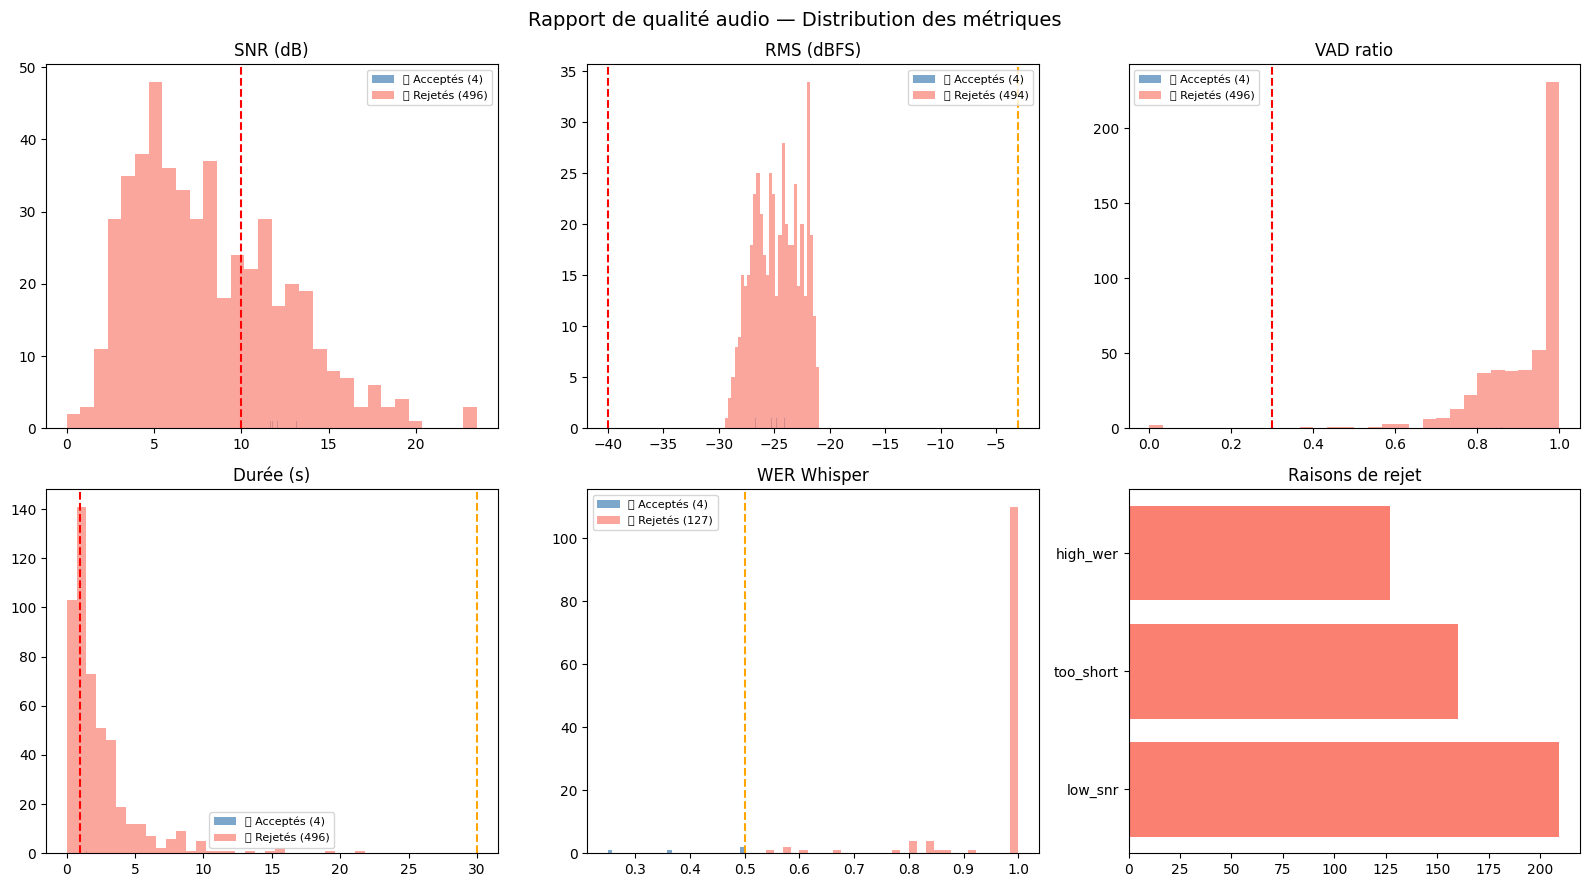

Rapport sauvegardé : /content/drive/MyDrive/asr/output/preprocessed/quality_report.png
CSV sauvegardé     : /content/drive/MyDrive/asr/output/preprocessed/quality_report.csv


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Rapport de qualité audio — Distribution des métriques', fontsize=14)

plots = [
    ('snr_db',       'SNR (dB)',       CONFIG['min_snr_db'],  None),
    ('rms_db',       'RMS (dBFS)',      CONFIG['min_rms_db'],  CONFIG['max_rms_db']),
    ('vad_ratio',    'VAD ratio',       CONFIG['min_vad_ratio'], None),
    ('duration_sec', 'Durée (s)',       CONFIG['min_duration_sec'], CONFIG['max_duration_sec']),
    ('wer',          'WER Whisper',     None, CONFIG['max_wer_threshold']),
]

for ax, (col, label, lo, hi) in zip(axes.flatten()[:5], plots):
    d_pass = quality_df[quality_df['passed']][col].dropna()
    d_rej  = quality_df[~quality_df['passed']][col].dropna()
    ax.hist(d_pass, bins=30, alpha=0.7, color='steelblue', label=f'✅ Acceptés ({len(d_pass)})')
    ax.hist(d_rej,  bins=30, alpha=0.7, color='salmon',    label=f'❌ Rejetés ({len(d_rej)})')
    if lo is not None: ax.axvline(lo, color='red',    linestyle='--', linewidth=1.5)
    if hi is not None: ax.axvline(hi, color='orange', linestyle='--', linewidth=1.5)
    ax.set_title(label)
    ax.legend(fontsize=8)

ax_rej = axes[1][2]
reasons = quality_df[~quality_df['passed']]['reject_reason']
counts  = reasons.str.split('(').str[0].str.strip().value_counts()
if not counts.empty:
    ax_rej.barh(counts.index, counts.values, color='salmon')
    ax_rej.set_title('Raisons de rejet')

plt.tight_layout()
viz_path = CONFIG['output_dir'] / 'quality_report.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Rapport sauvegardé : {viz_path}')

csv_path = CONFIG['output_dir'] / 'quality_report.csv'
quality_df.to_csv(csv_path, index=False)
print(f'CSV sauvegardé     : {csv_path}')

---
## Zone D : Augmentation des données

Pour chaque segment validé, `N` versions augmentées sont générées. Le texte de référence est **identique** pour toutes les versions — seul l'audio change.

Stratégies disponibles :
- `noise_white` / `noise_pink` / `noise_babble` — bruit additif à SNR contrôlé
- `rir_small` / `rir_medium` / `rir_large` — simulation acoustique par convolution RIR
- `time_stretch` — modification du tempo (±10%)
- `pitch_shift` — modification de la hauteur (±2 demi-tons)
- `volume` — perturbation du volume (±6 dB)
- `combined` — combinaison aléatoire de 2 techniques

In [12]:
from scipy.signal import fftconvolve

class AudioAugmenter:
    """
    Augmente les données audio pour l'entraînement ASR.
    Toutes les transformations préservent le label textuel.
    """

    STRATEGIES = [
        'noise_white', 'noise_pink', 'noise_babble',
        'rir_small', 'rir_medium', 'rir_large',
        'time_stretch', 'pitch_shift', 'volume', 'combined'
    ]

    def __init__(self, aug_dir: Path, sr: int = 16000, seed: int = 42):
        self.aug_dir = aug_dir
        self.sr      = sr
        self.rng     = np.random.default_rng(seed)
        self.aug_dir.mkdir(parents=True, exist_ok=True)
        self._rirs   = self._build_rirs()

    def _build_rirs(self) -> Dict[str, np.ndarray]:
        """Génère des RIR synthétiques pour 3 types de pièces."""
        rirs = {}
        for room, rt60 in [('small', 0.15), ('medium', 0.35), ('large', 0.70)]:
            duration = rt60 * 4
            t   = np.linspace(0, duration, int(duration * self.sr))
            rir = np.exp(-t / rt60) * self.rng.standard_normal(len(t))
            rir[0] = 1.0
            rir /= (np.max(np.abs(rir)) + 1e-10)
            rirs[room] = rir
        return rirs

    # ── Techniques individuelles ───────────────────────────────────────────

    def _add_noise(self, audio: np.ndarray, ntype: str,
                   snr_db: float) -> np.ndarray:
        sig_power = np.mean(audio ** 2) + 1e-10
        target_np = sig_power / (10 ** (snr_db / 10))
        if ntype == 'white':
            noise = self.rng.standard_normal(len(audio)).astype(np.float32)
        elif ntype == 'pink':
            w   = self.rng.standard_normal(len(audio))
            fft = np.fft.rfft(w)
            f   = np.fft.rfftfreq(len(w))
            f[0] = 1
            fft /= np.sqrt(f)
            noise = np.fft.irfft(fft, n=len(audio)).astype(np.float32)
        else:  # babble — bruit coloré simulant un fond de conversation
            noise = librosa.effects.preemphasis(
                self.rng.standard_normal(len(audio)).astype(np.float32)
            )
        noise_power = np.mean(noise ** 2) + 1e-10
        noise *= np.sqrt(target_np / noise_power)
        return np.clip(audio + noise, -1.0, 1.0)

    def _apply_rir(self, audio: np.ndarray, room: str) -> np.ndarray:
        rir = self._rirs[room]
        out = fftconvolve(audio, rir, mode='full')[:len(audio)]
        peak = np.max(np.abs(audio)) + 1e-10
        out  = out / (np.max(np.abs(out)) + 1e-10) * peak
        return np.clip(out, -1.0, 1.0).astype(np.float32)

    def _time_stretch(self, audio: np.ndarray) -> np.ndarray:
        rate = float(self.rng.uniform(*CONFIG['speed_range']))
        return librosa.effects.time_stretch(
            audio.astype(np.float32), rate=rate
        )

    def _pitch_shift(self, audio: np.ndarray) -> np.ndarray:
        steps = float(self.rng.uniform(*CONFIG['pitch_range_steps']))
        return librosa.effects.pitch_shift(
            audio.astype(np.float32), sr=self.sr, n_steps=steps
        )

    def _volume_perturb(self, audio: np.ndarray) -> np.ndarray:
        gain_db = float(self.rng.uniform(-6, 6))
        return np.clip(audio * 10 ** (gain_db / 20), -1.0, 1.0)

    def augment(self, audio: np.ndarray, strategy: str) -> np.ndarray:
        """Applique une stratégie d'augmentation nommée."""
        if strategy.startswith('noise_'):
            ntype  = strategy.split('_', 1)[1]
            snr_db = float(self.rng.uniform(*CONFIG['snr_range_db']))
            return self._add_noise(audio, ntype, snr_db)
        elif strategy.startswith('rir_'):
            return self._apply_rir(audio, strategy.split('_', 1)[1])
        elif strategy == 'time_stretch':
            return self._time_stretch(audio)
        elif strategy == 'pitch_shift':
            return self._pitch_shift(audio)
        elif strategy == 'volume':
            return self._volume_perturb(audio)
        elif strategy == 'combined':
            # Deux techniques aléatoires enchaînées
            pool = [s for s in self.STRATEGIES if s != 'combined']
            a, b = self.rng.choice(pool, size=2, replace=False)
            return self.augment(self.augment(audio, a), b)
        else:
            return audio

    # ── Pipeline batch ─────────────────────────────────────────────────────

    def augment_batch(self, pairs: List[Dict],
                      n_augments: int = 3) -> List[Dict]:
        """
        Génère N versions augmentées par segment.
        Les versions originales sont aussi incluses dans la sortie.
        """
        print('=' * 70)
        print('ZONE D : AUGMENTATION DES DONNÉES')
        print('=' * 70)
        print(f'   Segments originaux : {len(pairs)}')
        print(f'   Augmentations/seg  : {n_augments}')
        print(f'   Total attendu      : {len(pairs) * (1 + n_augments)}')
        print()

        all_pairs = list(pairs)  # Garder les originaux

        # Choisir les stratégies de manière cyclique
        strategy_pool = self.STRATEGIES[:-1]  # Exclure 'combined' du pool de rotation

        for pair in tqdm(pairs, desc='Augmentation'):
            audio_path = Path(pair['audio_path'])
            try:
                audio, _ = librosa.load(str(audio_path),
                                         sr=self.sr, mono=True)
            except Exception:
                continue

            for i in range(n_augments):
                strategy = strategy_pool[i % len(strategy_pool)]
                aug_id   = f"{pair['id']}_aug{i:02d}_{strategy.replace('_','')}"
                out_path = self.aug_dir / (aug_id + '.wav')

                if not out_path.exists():
                    try:
                        aug_audio = self.augment(audio, strategy)
                        sf.write(str(out_path), aug_audio, self.sr,
                                 subtype='PCM_16')
                    except Exception as e:
                        print(f'  ⚠️  aug error ({strategy}): {e}')
                        continue

                aug_pair = dict(pair)
                aug_pair['id']          = aug_id
                aug_pair['audio_path']  = out_path
                aug_pair['is_augmented'] = True
                aug_pair['aug_strategy'] = strategy
                all_pairs.append(aug_pair)

        orig  = len(pairs)
        total = len(all_pairs)
        print(f'\n   ✅ Originaux       : {orig}')
        print(f'   ✅ Augmentés        : {total - orig}')
        print(f'   ✅ Total dataset    : {total}')
        return all_pairs


augmenter  = AudioAugmenter(
    aug_dir=CONFIG['augmented_dir'],
    sr=CONFIG['sample_rate']
)
pairs_augmented = augmenter.augment_batch(
    pairs_passed,
    n_augments=CONFIG['augmentation_factor']
)

ZONE D : AUGMENTATION DES DONNÉES
   Segments originaux : 4
   Augmentations/seg  : 3
   Total attendu      : 16



Augmentation: 100%|██████████| 4/4 [00:00<00:00,  4.57it/s]


   ✅ Originaux       : 4
   ✅ Augmentés        : 12
   ✅ Total dataset    : 16


---
## Zone E : Export JSONL — Dataset final pour Whisper

In [13]:
import random

def export_jsonl(pairs: List[Dict], out_dir: Path,
                 train_ratio: float = 0.85) -> Dict[str, Path]:
    """
    Exporte le dataset en JSONL avec split train/validation.

    Format de sortie par ligne :
        {
            "audio_path": "/chemin/vers/audio.wav",
            "text": "transcription de référence",
            "id": "segment_id",
            "speaker": "speaker_id",
            "is_augmented": false,
            "aug_strategy": null,
            "quality": {"snr_db": 18.2, "rms_db": -22.1, ...}
        }
    """
    print('=' * 70)
    print('ZONE E : EXPORT JSONL')
    print('=' * 70)

    # Séparer originaux / augmentés pour un split équitable
    originals  = [p for p in pairs if not p.get('is_augmented', False)]
    augmented  = [p for p in pairs if p.get('is_augmented', False)]

    random.shuffle(originals)
    split_idx  = int(len(originals) * train_ratio)
    train_ids  = {p['id'] for p in originals[:split_idx]}

    train_pairs = [p for p in pairs
                   if p['id'] in train_ids or
                   (p.get('is_augmented') and
                    # L'augmenté suit son original
                    '_aug' in p['id'] and
                    p['id'].rsplit('_aug', 1)[0] in train_ids)]
    val_pairs   = [p for p in originals if p['id'] not in train_ids]

    def write(path: Path, data: List[Dict]):
        with open(path, 'w', encoding='utf-8') as f:
            for p in data:
                row = {
                    'audio_path'   : str(p['audio_path']),
                    'text'         : p.get('text', ''),
                    'id'           : p.get('id', ''),
                    'speaker'      : p.get('speaker', 'unknown'),
                    'is_augmented' : p.get('is_augmented', False),
                    'aug_strategy' : p.get('aug_strategy', None),
                    'sep_method'   : p.get('sep_method', None),
                    'quality'      : p.get('quality', {}),
                }
                f.write(json.dumps(row, ensure_ascii=False) + '\n')

    train_path = out_dir / 'train.jsonl'
    val_path   = out_dir / 'validation.jsonl'

    write(train_path, train_pairs)
    write(val_path,   val_pairs)

    # Sauvegarder aussi les rejetés pour audit
    reject_path = out_dir / 'rejected.jsonl'
    quality_df.to_json(reject_path, orient='records', lines=True, force_ascii=False)

    print(f'\n   Train      : {len(train_pairs):>6} segments  → {train_path}')
    print(f'   Validation : {len(val_pairs):>6} segments  → {val_path}')
    print(f'   Rejetés    : {len(pairs_rejected):>6} segments  → {reject_path}')

    return {'train': train_path, 'validation': val_path, 'rejected': reject_path}


output_files = export_jsonl(
    pairs_augmented,
    out_dir=CONFIG['output_dir'],
    train_ratio=0.85
)

ZONE E : EXPORT JSONL

   Train      :     12 segments  → /content/drive/MyDrive/asr/output/preprocessed/train.jsonl
   Validation :      1 segments  → /content/drive/MyDrive/asr/output/preprocessed/validation.jsonl
   Rejetés    :    496 segments  → /content/drive/MyDrive/asr/output/preprocessed/rejected.jsonl


---
## Résumé du pipeline

In [14]:
passed_orig = [p for p in pairs_passed if not p.get('is_augmented', False)]
augmented   = [p for p in pairs_augmented if p.get('is_augmented', False)]

print('=' * 70)
print('RÉSUMÉ PIPELINE')
print('=' * 70)
print(f'  Entrée brute             : {len(raw_pairs):>6} paires')
print(f'  Après normalisation      : {len(pairs_normalized):>6}')
print(f'  Après séparation voix    : {len(pairs_voice):>6}')
print(f'  ✅ Après filtres qualité  : {len(pairs_passed):>6}')
print(f'  ❌ Rejetés (qualité)      : {len(pairs_rejected):>6}')
print(f'  + Segments augmentés     : {len(augmented):>6}')
print(f'  ═══════════════════════════════════')
print(f'  Dataset final (train+val): {len(pairs_augmented):>6} segments')
print()
print('  Fichiers de sortie :')
for k, v in output_files.items():
    print(f'    {k:<12} → {v}')
print('=' * 70)

RÉSUMÉ PIPELINE
  Entrée brute             :    500 paires
  Après normalisation      :    500
  Après séparation voix    :    500
  ✅ Après filtres qualité  :      4
  ❌ Rejetés (qualité)      :    496
  + Segments augmentés     :     12
  ═══════════════════════════════════
  Dataset final (train+val):     16 segments

  Fichiers de sortie :
    train        → /content/drive/MyDrive/asr/output/preprocessed/train.jsonl
    validation   → /content/drive/MyDrive/asr/output/preprocessed/validation.jsonl
    rejected     → /content/drive/MyDrive/asr/output/preprocessed/rejected.jsonl
